# Hyperparameter Optimization with Optuna on MovieLens 1M

This notebook demonstrates the **recommender-level HPO** module powered by
[Optuna](https://optuna.readthedocs.io/).  We optimise an XGBoost ranking
pipeline end-to-end — the HPO loop trains the full
`Estimator → Scorer → Recommender` pipeline on each trial and evaluates it
with recommendation metrics (NDCG@k, Precision@k).

**What this notebook covers:**
1. Data preparation (same MovieLens 1M setup as `ranking_xgboost_movielens1m.ipynb`)
2. Defining a search space with plain Python dicts
3. Running optimisation with **TPE** (default), **Gaussian Process**, and **CMA-ES** samplers
4. Inspecting results and Optuna's built-in visualisations
5. Training a final model with the best parameters

**Prerequisites:** Run `ranking_xgboost_movielens1m.ipynb` first (or just have the
`data/ml-1m/` folder populated — this notebook downloads it if missing).

## 1. Imports

In [1]:
import logging
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import optuna
import pandas as pd

from skrec.dataset.interactions_dataset import InteractionsDataset
from skrec.dataset.items_dataset import ItemsDataset
from skrec.orchestrator.hpo import HyperparameterOptimizer

# Keep logs concise — optuna and the library are both chatty
logging.basicConfig(level=logging.WARNING)
logging.getLogger("recommender").setLevel(logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.WARNING)

RAW_DIR = Path("data/movielens-1m")
RAW_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("data/hpo-xgboost")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Imports OK")

/Users/ssankararam/Shankar/Personal/RecSys/scikit-rec/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 2. Download and Prepare MovieLens 1M

Same setup as `ranking_xgboost_movielens1m.ipynb`:
- Binary label: rating >= 4 is positive
- User features: gender, age, occupation
- Item features: genre one-hot encoding
- Leave-last-positive-out split

In [2]:
# --- Download ---
ML1M_URL = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
zip_path = RAW_DIR / "ml-1m.zip"

if not (RAW_DIR / "ratings.dat").exists():
    print("Downloading MovieLens 1M...")
    urllib.request.urlretrieve(ML1M_URL, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        for name in zf.namelist():
            if name.endswith(".dat"):
                filename = Path(name).name
                with zf.open(name) as src, open(RAW_DIR / filename, "wb") as dst:
                    dst.write(src.read())
    print("Downloaded and extracted.")
else:
    print("Already downloaded.")

# --- Load raw data ---
ratings = pd.read_csv(
    RAW_DIR / "ratings.dat", sep="::", engine="python", names=["UserID", "MovieID", "Rating", "Timestamp"]
)
movies = pd.read_csv(
    RAW_DIR / "movies.dat", sep="::", engine="python", names=["MovieID", "Title", "Genres"], encoding="latin-1"
)
users_raw = pd.read_csv(
    RAW_DIR / "users.dat", sep="::", engine="python", names=["UserID", "Gender", "Age", "Occupation", "Zip"]
)

# --- Item features: genre one-hot ---
genre_dummies = movies.Genres.str.get_dummies(sep="|").add_prefix("genre_")
items_df = pd.concat([movies[["MovieID"]].rename(columns={"MovieID": "ITEM_ID"}), genre_dummies], axis=1)
items_df["ITEM_ID"] = items_df["ITEM_ID"].astype(str)

# --- User features ---
users_feat = users_raw[["UserID", "Gender", "Age", "Occupation"]].copy()
users_feat["gender_M"] = (users_feat["Gender"] == "M").astype(int)
users_feat = users_feat.rename(columns={"Age": "age", "Occupation": "occupation"})
users_feat = users_feat[["UserID", "gender_M", "age", "occupation"]]

# --- Interactions: binary label ---
interactions = ratings.merge(users_feat, on="UserID", how="left")
interactions = pd.DataFrame(
    {
        "USER_ID": interactions["UserID"].astype(str),
        "ITEM_ID": interactions["MovieID"].astype(str),
        "OUTCOME": (interactions["Rating"] >= 4).astype(float),
        "TIMESTAMP": interactions["Timestamp"],
        "gender_M": interactions["gender_M"],
        "age": interactions["age"],
        "occupation": interactions["occupation"],
    }
)

# --- Leave-last-positive-out split ---
interactions = interactions.sort_values(["USER_ID", "TIMESTAMP"]).reset_index(drop=True)
user_counts = interactions.groupby("USER_ID").size()
valid_users = user_counts[user_counts >= 3].index
interactions = interactions[interactions["USER_ID"].isin(valid_users)].reset_index(drop=True)

pos_interactions = interactions[interactions["OUTCOME"] == 1.0].copy()
last_pos_idx = pos_interactions.groupby("USER_ID")["TIMESTAMP"].idxmax()
test_df = pos_interactions.loc[last_pos_idx].reset_index(drop=True)
train_df = interactions.drop(index=last_pos_idx).reset_index(drop=True)
test_df = test_df[test_df["USER_ID"].isin(train_df["USER_ID"].unique())].reset_index(drop=True)

# --- Save CSVs and create Dataset objects ---
train_path = str(DATA_DIR / "train_interactions.csv")
val_path = str(DATA_DIR / "val_interactions.csv")
items_path = str(DATA_DIR / "items.csv")

# For HPO we need a validation set. We'll use the test set as the validation
# target for the HPO loop (in practice you'd use a separate validation split).
if not Path(train_path).exists():
    train_df.drop(columns=["TIMESTAMP"]).to_csv(train_path, index=False)
if not Path(val_path).exists():
    test_df.drop(columns=["TIMESTAMP"]).to_csv(val_path, index=False)
if not Path(items_path).exists():
    items_df.to_csv(items_path, index=False)

train_interactions_ds = InteractionsDataset(data_location=train_path)
val_interactions_ds = InteractionsDataset(data_location=val_path)
items_ds = ItemsDataset(data_location=items_path)

print(f"Train : {len(train_df):,} interactions")
print(f"Val   : {len(test_df):,} interactions (leave-last-positive-out)")
print(f"Items : {len(items_df):,} movies")

Already downloaded.


Train : 994,171 interactions
Val   : 6,038 interactions (leave-last-positive-out)
Items : 3,883 movies


## 3. Define the HPO Configuration

The HPO module needs three things:

1. **Base config** — a dict that `create_recommender_pipeline()` understands.
   This defines the *fixed* parts of the pipeline (scorer type, recommender type,
   XGBoost defaults that won't be tuned).

2. **Search space** — a dict mapping dot-notation parameter paths to dimension specs.
   Each spec is a plain Python dict with `type` (`"int"`, `"float"`, or `"categorical"`)
   and the appropriate bounds. No special imports needed.

3. **Metric definitions** — which recommendation metrics to compute on the validation set.
   The first call to `run_optimization` will specify which one is the *objective*.

In [3]:
# --- Base pipeline config (fixed parts) ---
base_config = {
    "estimator_config": {
        "ml_task": "classification",
        "xgboost": {
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "use_label_encoder": False,
            "random_state": 42,
            "n_jobs": -1,
        },
    },
    "scorer_type": "universal",
    "recommender_type": "ranking",
}

# --- Search space ---
# Keys use dot-notation to reach into the nested config.
# Each value is a plain dict describing the dimension.
search_space = {
    "estimator_config.xgboost.n_estimators": {"type": "int", "low": 50, "high": 200},
    "estimator_config.xgboost.max_depth": {"type": "int", "low": 3, "high": 7},
    "estimator_config.xgboost.learning_rate": {"type": "float", "low": 0.01, "high": 0.3, "log": True},
    "estimator_config.xgboost.subsample": {"type": "float", "low": 0.5, "high": 1.0},
    "estimator_config.xgboost.colsample_bytree": {"type": "float", "low": 0.5, "high": 1.0},
}

# --- Metrics to track ---
metric_definitions = ["NDCG@10", "Precision@10"]

print("Base config, search space, and metrics defined.")
print(f"  Tuning {len(search_space)} hyperparameters")
print(f"  Tracking {len(metric_definitions)} metrics: {metric_definitions}")

Base config, search space, and metrics defined.
  Tuning 5 hyperparameters
  Tracking 2 metrics: ['NDCG@10', 'Precision@10']


## 4. Create the HyperparameterOptimizer

The optimizer wraps the full train-evaluate loop. On each trial it:
1. Merges suggested hyperparameters into the base config
2. Creates the pipeline via the orchestrator factory
3. Trains the model
4. Evaluates all metrics on the validation set
5. Persists results incrementally (optional)

In [4]:
# Clean up any stale results from previous runs
persistence_path = str(DATA_DIR / "hpo_results.parquet")
Path(persistence_path).unlink(missing_ok=True)

hpo = HyperparameterOptimizer(
    base_config=base_config,
    search_space=search_space,
    metric_definitions=metric_definitions,
    training_interactions_ds=train_interactions_ds,
    validation_interactions_ds=val_interactions_ds,
    training_items_ds=items_ds,
    evaluator_type="simple",
    persistence_path=persistence_path,
)

print("HyperparameterOptimizer created.")

2026-04-16 22:53:16,255 - skrec.orchestrator.hpo - INFO Attempting to load previous results from data/hpo-xgboost/hpo_results.parquet...


INFO:skrec.orchestrator.hpo:Attempting to load previous results from data/hpo-xgboost/hpo_results.parquet...


2026-04-16 22:53:16,325 - skrec.orchestrator.hpo - WARNING Persistence file not found at data/hpo-xgboost/hpo_results.parquet. Starting fresh.


2026-04-16 22:53:16,326 - skrec.orchestrator.hpo - INFO HyperparameterOptimizer initialized. Persistence path: data/hpo-xgboost/hpo_results.parquet


INFO:skrec.orchestrator.hpo:HyperparameterOptimizer initialized. Persistence path: data/hpo-xgboost/hpo_results.parquet


HyperparameterOptimizer created.


## 5. Run Optimization with TPE (Default)

**TPE** (Tree-structured Parzen Estimator) is Optuna's default sampler.
It models the density of "good" vs "bad" parameter regions independently
per dimension, making it efficient for mixed (continuous + categorical)
spaces and scales well to many trials.

We run 5 trials here for speed — in practice you'd use 50-200+.

> **Evaluation protocol note:** The HPO evaluator ranks each test item against the
> **full item catalog** (3,706 movies). This is much harder than the *sampled ranking*
> protocol in `ranking_xgboost_movielens1m.ipynb` (1 positive vs 100 random negatives),
> so absolute NDCG/Precision values here will be lower. What matters for HPO is the
> *relative ordering* between trials — the optimizer correctly identifies which
> hyperparameter configs produce better rankings.

In [5]:
results_df, study_tpe = hpo.run_optimization(
    n_trials=5,
    objective_metric="NDCG@10",
    sampler="tpe",
    sampler_kwargs={"seed": 42},  # for reproducibility
    direction="maximize",
)

print(f"\nTPE: {len(study_tpe.trials)} trials completed")
print(f"Best NDCG@10 : {study_tpe.best_value:.4f}")
print(f"Best params  : {study_tpe.best_params}")

2026-04-16 22:53:16,330 - skrec.orchestrator.hpo - INFO Starting Optuna optimization: 5 trials, sampler=TPESampler, metric=NDCG@10, direction=maximize


INFO:skrec.orchestrator.hpo:Starting Optuna optimization: 5 trials, sampler=TPESampler, metric=NDCG@10, direction=maximize


2026-04-16 22:53:16,331 - skrec.orchestrator.hpo - INFO Starting trial with params: {'estimator_config.xgboost.n_estimators': 106, 'estimator_config.xgboost.max_depth': 7, 'estimator_config.xgboost.learning_rate': 0.1205712628744377, 'estimator_config.xgboost.subsample': 0.7993292420985183, 'estimator_config.xgboost.colsample_bytree': 0.5780093202212182}


INFO:skrec.orchestrator.hpo:Starting trial with params: {'estimator_config.xgboost.n_estimators': 106, 'estimator_config.xgboost.max_depth': 7, 'estimator_config.xgboost.learning_rate': 0.1205712628744377, 'estimator_config.xgboost.subsample': 0.7993292420985183, 'estimator_config.xgboost.colsample_bytree': 0.5780093202212182}


2026-04-16 22:53:16,331 - skrec.orchestrator.factory - INFO Creating recommender pipeline from config...


...

2026-04-16 22:55:34,108 - skrec.orchestrator.hpo - INFO Optimization finished. Best value: 0.0038


INFO:skrec.orchestrator.hpo:Optimization finished. Best value: 0.0038


2026-04-16 22:55:34,108 - skrec.orchestrator.hpo - INFO Best parameters: {'estimator_config.xgboost.n_estimators': 73, 'estimator_config.xgboost.max_depth': 3, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}


INFO:skrec.orchestrator.hpo:Best parameters: {'estimator_config.xgboost.n_estimators': 73, 'estimator_config.xgboost.max_depth': 3, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}



TPE: 5 trials completed
Best NDCG@10 : 0.0038
Best params  : {'estimator_config.xgboost.n_estimators': 73, 'estimator_config.xgboost.max_depth': 3, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}


## 6. Inspect Results

The `results_df` DataFrame contains one row per trial across *all* runs
(including any previous results loaded from the persistence path).
Every hyperparameter and every tracked metric is a column.

In [6]:
# Show all trials sorted by objective metric
results_df.sort_values("NDCG@10", ascending=False).head(10)

,estimator_config.xgboost.n_estimators,estimator_config.xgboost.max_depth,estimator_config.xgboost.learning_rate,estimator_config.xgboost.subsample,estimator_config.xgboost.colsample_bytree,NDCG@10,Precision@10,trial_duration
1,73,3,0.190304,0.800558,0.854036,0.003822,0.000679,27.019378
2,53,7,0.169675,0.606170,0.590912,0.003261,0.000762,26.540539
4,142,3,0.027011,0.683181,0.728035,0.003222,0.000629,27.093162
3,77,4,0.059584,0.715973,0.645615,0.002857,0.000397,27.289526
0,106,7,0.120571,0.799329,0.578009,0.002618,0.000613,29.812975


## 7. Try a Different Sampler: Gaussian Process

**GP** (Gaussian Process) fits a full surrogate model over the objective surface.
It's the most sample-efficient for low-dimensional continuous spaces (< 10 params)
but scales as O(n^3) in the number of completed trials.

Since the `HyperparameterOptimizer` accumulates results across runs, the GP sampler
will automatically be warm-started with the TPE trials above.

In [7]:
results_df, study_gp = hpo.run_optimization(
    n_trials=3,
    objective_metric="NDCG@10",
    sampler="gp",
    sampler_kwargs={"seed": 42},
    direction="maximize",
)

print(f"\nGP: {len(study_gp.trials)} trials completed (including warm-start)")
print(f"Best NDCG@10 : {study_gp.best_value:.4f}")
print(f"Best params  : {study_gp.best_params}")

/Users/ssankararam/Shankar/Personal/RecSys/scikit-rec/skrec/orchestrator/hpo.py:112: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  return _SAMPLER_REGISTRY[key](**(sampler_kwargs or {}))
2026-04-16 22:55:34,123 - skrec.orchestrator.hpo - INFO Starting Optuna optimization: 3 trials, sampler=GPSampler, metric=NDCG@10, direction=maximize


INFO:skrec.orchestrator.hpo:Starting Optuna optimization: 3 trials, sampler=GPSampler, metric=NDCG@10, direction=maximize


2026-04-16 22:55:34,125 - skrec.orchestrator.hpo - INFO Warm-started study with 5 previous trials.


INFO:skrec.orchestrator.hpo:Warm-started study with 5 previous trials.


2026-04-16 22:55:34,125 - skrec.orchestrator.hpo - INFO Starting trial with params: {'estimator_config.xgboost.n_estimators': 106, 'estimator_config.xgboost.max_depth': 7, 'estimator_config.xgboost.learning_rate': 0.1205712628744377, 'estimator_config.xgboost.subsample': 0.7993292420985183, 'estimator_config.xgboost.colsample_bytree': 0.5780093202212182}


...

2026-04-16 22:56:55,967 - skrec.orchestrator.hpo - INFO Optimization finished. Best value: 0.0038


INFO:skrec.orchestrator.hpo:Optimization finished. Best value: 0.0038


2026-04-16 22:56:55,968 - skrec.orchestrator.hpo - INFO Best parameters: {'estimator_config.xgboost.n_estimators': 73.0, 'estimator_config.xgboost.max_depth': 3.0, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}


INFO:skrec.orchestrator.hpo:Best parameters: {'estimator_config.xgboost.n_estimators': 73.0, 'estimator_config.xgboost.max_depth': 3.0, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}



GP: 8 trials completed (including warm-start)
Best NDCG@10 : 0.0038
Best params  : {'estimator_config.xgboost.n_estimators': 73.0, 'estimator_config.xgboost.max_depth': 3.0, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}


## 8. Try CMA-ES

**CMA-ES** (Covariance Matrix Adaptation Evolution Strategy) is a derivative-free
evolutionary algorithm. It excels at continuous optimisation and learns parameter
correlations — e.g., it can discover that high `learning_rate` works best with
low `n_estimators`.

Note: CMA-ES treats categorical parameters as continuous internally, so it's
best suited for search spaces that are mostly numeric.

In [8]:
results_df, study_cma = hpo.run_optimization(
    n_trials=3,
    objective_metric="NDCG@10",
    sampler="cmaes",
    sampler_kwargs={"seed": 42},
    direction="maximize",
)

print(f"\nCMA-ES: {len(study_cma.trials)} trials completed (including warm-start)")
print(f"Best NDCG@10 : {study_cma.best_value:.4f}")
print(f"Best params  : {study_cma.best_params}")

2026-04-16 22:56:55,972 - skrec.orchestrator.hpo - INFO Starting Optuna optimization: 3 trials, sampler=CmaEsSampler, metric=NDCG@10, direction=maximize


INFO:skrec.orchestrator.hpo:Starting Optuna optimization: 3 trials, sampler=CmaEsSampler, metric=NDCG@10, direction=maximize


2026-04-16 22:56:55,974 - skrec.orchestrator.hpo - INFO Warm-started study with 8 previous trials.


INFO:skrec.orchestrator.hpo:Warm-started study with 8 previous trials.


2026-04-16 22:56:55,983 - skrec.orchestrator.hpo - INFO Starting trial with params: {'estimator_config.xgboost.n_estimators': 73, 'estimator_config.xgboost.max_depth': 5, 'estimator_config.xgboost.learning_rate': 0.04820837985386907, 'estimator_config.xgboost.subsample': 0.7119302093300406, 'estimator_config.xgboost.colsample_bytree': 0.5720001268166836}


...

2026-04-16 22:58:19,339 - skrec.orchestrator.hpo - INFO Optimization finished. Best value: 0.0038


INFO:skrec.orchestrator.hpo:Optimization finished. Best value: 0.0038


2026-04-16 22:58:19,339 - skrec.orchestrator.hpo - INFO Best parameters: {'estimator_config.xgboost.n_estimators': 73.0, 'estimator_config.xgboost.max_depth': 3.0, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}


INFO:skrec.orchestrator.hpo:Best parameters: {'estimator_config.xgboost.n_estimators': 73.0, 'estimator_config.xgboost.max_depth': 3.0, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}



CMA-ES: 11 trials completed (including warm-start)
Best NDCG@10 : 0.0038
Best params  : {'estimator_config.xgboost.n_estimators': 73.0, 'estimator_config.xgboost.max_depth': 3.0, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}


## 9. Using a Custom Sampler Instance

For full control, pass an `optuna.samplers.BaseSampler` instance directly.
This lets you configure every knob — e.g., TPE with more startup trials,
a specific multivariate mode, or a custom prior.

In [9]:
# Example: multivariate TPE considers parameter interactions (joint distribution)
# rather than sampling each dimension independently.
custom_sampler = optuna.samplers.TPESampler(
    n_startup_trials=5,  # random trials before TPE kicks in
    multivariate=True,  # model joint parameter distribution
    seed=123,
)

results_df, study_custom = hpo.run_optimization(
    n_trials=3,
    objective_metric="NDCG@10",
    sampler=custom_sampler,  # pass the instance directly
    direction="maximize",
)

print(f"\nCustom TPE: {len(study_custom.trials)} trials completed (including warm-start)")
print(f"Best NDCG@10 : {study_custom.best_value:.4f}")
print(f"Best params  : {study_custom.best_params}")

/var/folders/3b/pjpj9w4939j9cmn303gsmtl00000gr/T/ipykernel_85431/3834856603.py:3: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  custom_sampler = optuna.samplers.TPESampler(
2026-04-16 22:58:19,344 - skrec.orchestrator.hpo - INFO Starting Optuna optimization: 3 trials, sampler=TPESampler, metric=NDCG@10, direction=maximize


INFO:skrec.orchestrator.hpo:Starting Optuna optimization: 3 trials, sampler=TPESampler, metric=NDCG@10, direction=maximize


2026-04-16 22:58:19,346 - skrec.orchestrator.hpo - INFO Warm-started study with 11 previous trials.


INFO:skrec.orchestrator.hpo:Warm-started study with 11 previous trials.


2026-04-16 22:58:19,348 - skrec.orchestrator.hpo - INFO Starting trial with params: {'estimator_config.xgboost.n_estimators': 63, 'estimator_config.xgboost.max_depth': 3, 'estimator_config.xgboost.learning_rate': 0.23237919998969012, 'estimator_config.xgboost.subsample': 0.7718863065242327, 'estimator_config.xgboost.colsample_bytree': 0.8694393650237212}


...

2026-04-16 22:59:37,825 - skrec.orchestrator.hpo - INFO Optimization finished. Best value: 0.0038


INFO:skrec.orchestrator.hpo:Optimization finished. Best value: 0.0038


2026-04-16 22:59:37,826 - skrec.orchestrator.hpo - INFO Best parameters: {'estimator_config.xgboost.n_estimators': 73.0, 'estimator_config.xgboost.max_depth': 3.0, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}


INFO:skrec.orchestrator.hpo:Best parameters: {'estimator_config.xgboost.n_estimators': 73.0, 'estimator_config.xgboost.max_depth': 3.0, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}



Custom TPE: 14 trials completed (including warm-start)
Best NDCG@10 : 0.0038
Best params  : {'estimator_config.xgboost.n_estimators': 73.0, 'estimator_config.xgboost.max_depth': 3.0, 'estimator_config.xgboost.learning_rate': 0.19030368381735815, 'estimator_config.xgboost.subsample': 0.8005575058716043, 'estimator_config.xgboost.colsample_bytree': 0.8540362888980227}


## 10. Aggregate Results

All trials across all sampler runs are accumulated in `results_df`.
Let's see the overall best configurations and compare sampler performance.

In [10]:
print(f"Total trials run: {len(results_df)}")
print("\nTop 5 configurations by NDCG@10:")
top5 = results_df.sort_values("NDCG@10", ascending=False).head(5)
display(top5)

# Summary stats
print("\nNDCG@10 across all trials:")
print(f"  Mean  : {results_df['NDCG@10'].mean():.4f}")
print(f"  Std   : {results_df['NDCG@10'].std():.4f}")
print(f"  Min   : {results_df['NDCG@10'].min():.4f}")
print(f"  Max   : {results_df['NDCG@10'].max():.4f}")

Total trials run: 14

Top 5 configurations by NDCG@10:


,estimator_config.xgboost.n_estimators,estimator_config.xgboost.max_depth,estimator_config.xgboost.learning_rate,estimator_config.xgboost.subsample,estimator_config.xgboost.colsample_bytree,NDCG@10,Precision@10,trial_duration
1,73,3,0.190304,0.800558,0.854036,0.003822,0.000679,27.019378
6,73,3,0.190304,0.800558,0.854036,0.003822,0.000679,25.443357
2,53,7,0.169675,0.606170,0.590912,0.003261,0.000762,26.540539
7,53,7,0.169675,0.606170,0.590912,0.003261,0.000762,27.149300
4,142,3,0.027011,0.683181,0.728035,0.003222,0.000629,27.093162



NDCG@10 across all trials:
  Mean  : 0.0029
  Std   : 0.0006
  Min   : 0.0018
  Max   : 0.0038


## 11. Optuna Visualisations

Optuna provides built-in plotting functions that work directly on the Study object.
These are useful for understanding the optimisation landscape.

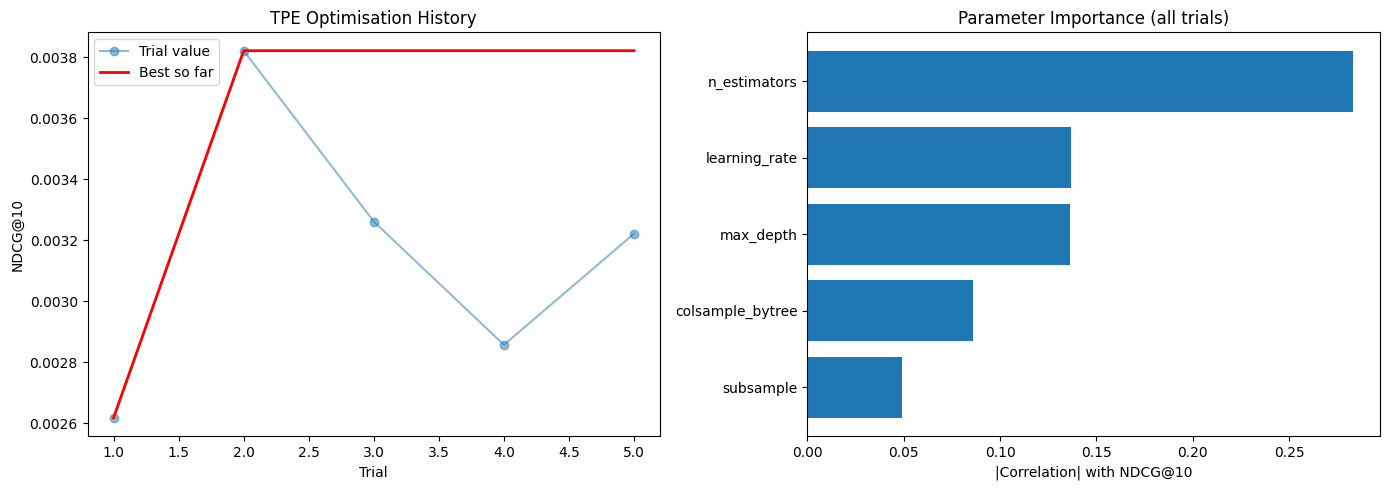

In [11]:
import matplotlib.pyplot as plt

# Use the TPE study (largest) for visualisations.
# If plotly is installed, optuna.visualization provides interactive plots.
# Here we use matplotlib for simplicity.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Optimisation history ---
trials = study_tpe.trials
values = [t.value for t in trials if t.value is not None]
best_so_far = [max(values[: i + 1]) for i in range(len(values))]

axes[0].plot(range(1, len(values) + 1), values, "o-", alpha=0.5, label="Trial value")
axes[0].plot(range(1, len(best_so_far) + 1), best_so_far, "r-", linewidth=2, label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("NDCG@10")
axes[0].set_title("TPE Optimisation History")
axes[0].legend()

# --- Plot 2: Parameter importance (correlation with objective) ---
param_cols = list(search_space.keys())
short_names = [p.split(".")[-1] for p in param_cols]
correlations = []
for col in param_cols:
    corr = results_df[col].corr(results_df["NDCG@10"])
    correlations.append(abs(corr) if not np.isnan(corr) else 0.0)

sorted_idx = np.argsort(correlations)
axes[1].barh([short_names[i] for i in sorted_idx], [correlations[i] for i in sorted_idx])
axes[1].set_xlabel("|Correlation| with NDCG@10")
axes[1].set_title("Parameter Importance (all trials)")

plt.tight_layout()
plt.show()

## 12. Train Final Model with Best Parameters

Extract the best hyperparameters and train a production model using the
standard `Estimator → Scorer → Recommender` API.

In [12]:
from skrec.estimator.classification.xgb_classifier import XGBClassifierEstimator
from skrec.recommender.ranking.ranking_recommender import RankingRecommender
from skrec.scorer.universal import UniversalScorer

# Get the best trial across ALL runs
best_row = results_df.sort_values("NDCG@10", ascending=False).iloc[0]
print("Best hyperparameters found:")

# Extract just the XGBoost params from the dotted keys
best_xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "use_label_encoder": False,
    "random_state": 42,
    "n_jobs": -1,
}
for key, spec in search_space.items():
    short_key = key.split(".")[-1]
    value = best_row[key]
    # Coerce to declared type — results_df may store ints as floats
    if spec["type"] == "int":
        value = int(value)
    elif spec["type"] == "float":
        value = float(value)
    best_xgb_params[short_key] = value
    print(f"  {short_key}: {value}")

print(f"\n  NDCG@10: {best_row['NDCG@10']:.4f}  |  Precision@10: {best_row['Precision@10']:.4f}")

# Build and train the final model
estimator = XGBClassifierEstimator(params=best_xgb_params)
scorer = UniversalScorer(estimator)
recommender = RankingRecommender(scorer)

recommender.train(
    interactions_ds=train_interactions_ds,
    items_ds=items_ds,
)
print("\nFinal model trained with best HPO parameters.")

Best hyperparameters found:
  n_estimators: 73
  max_depth: 3
  learning_rate: 0.19030368381735815
  subsample: 0.8005575058716043
  colsample_bytree: 0.8540362888980227

  NDCG@10: 0.0038  |  Precision@10: 0.0007


/Users/ssankararam/Shankar/Personal/RecSys/scikit-rec/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:59:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Final model trained with best HPO parameters.


## 13. Sampler Reference

| Sampler | String key | Best for | Notes |
|---|---|---|---|
| **TPE** | `"tpe"` | General purpose, mixed types | Default. O(n log n). Handles categorical natively. |
| **GP** | `"gp"` | Low-dim continuous, small budgets | Most sample-efficient. O(n^3). Requires optuna >= 4.0. |
| **CMA-ES** | `"cmaes"` | Continuous params with correlations | Learns covariance structure. Not ideal for categoricals. |
| **QMC** | `"qmc"` | Space-filling exploration | Quasi-Monte Carlo. Better coverage than pure random. |
| **Random** | `"random"` | Baselines, debugging | Pure random search via optuna. |
| **Grid** | `"grid"` | Exhaustive search over discrete grid | Requires `search_space` values with finite choices. |
| **Custom** | Pass instance | Full control | Any `optuna.samplers.BaseSampler` subclass. |

All samplers are used via the same `run_optimization()` call — just change the `sampler` argument.